# DATA 606 Capstone Deliverable: Proposal EDA

**Author:** Brett Allen (ballen3@umbc.edu)

**Topic:** Air Traffic Controller (ATC) Communications Intelligence

*Speech Recognition and Information Extraction for Aviation Safety*

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configurations](#configurations)
- [Data Ingestion](#data-ingestion)
  - [ATCO2-ASR Dataset](#atco2-asr-dataset)
  - [ATCOSIM Dataset](#atcosim-dataset)
  - [Join Datasets](#join-datasets)
  - [Data Dictionary](#data-dictionary)
  - [Analyze Derived Features](#analyze-derived-features)
    - [`sample_rate`](#sample_rate)
    - [`duration_sec`](#duration_sec)
    - [`word_count` & `character_count`](#word_count-character_count)
    - [`speech_rate_wpm`](#speech_rate_wpm)
    - [`dataset_split` & `original_split`](#dataset_split-original_split)
  - [Validate the Join & Document Imbalance](#validate-the-join-document-imbalance)
- [Data Quality Checks](#data-quality-checks)
  - [Missing audio](#missing-audio)
  - [Missing & blank transcripts](#missing-blank-transcripts)
  - [Missing & structurally unavailable metadata](#missing-structurally-unavailable-metadata)
  - [Zero-duration or unreadable audio](#zero-duration-or-unreadable-audio)
  - [Duplicate IDs, file paths, and audio/transcript pairs](#duplicate-ids-file-paths-and-audiotranscript-pairs)
  - [Repeated transcript text](#repeated-transcript-text)
  - [Data Quality Summary & Proposed Handling](#data-quality-summary-proposed-handling)
- [Preliminary EDA](#preliminary-eda)
  - [Representative Audio Samples (per Corpus)](#representative-audio-samples-per-corpus)
  - [Waveform & Mel Spectrogram](#waveform-mel-spectrogram)
  - [ATCO2 `info`/Annotation Examples](#atco2-infoannotation-examples)
    - [Recording Date Range](#recording-date-range)
  - [Preliminary Findings](#preliminary-findings)
  - [Implications for the Modeling Plan](#implications-for-the-modeling-plan)

## Setup

In [1]:
!python --version

Python 3.12.9


In [2]:
!cat ../requirements.txt

# Python 3.12.4
datasets==3.2.0
transformers==4.57.6
librosa==1.0.0
soundfile==0.14.0
coverage>=7.7.0  # numba's coverage integration needs coverage.types.Tracer (added in 7.7.0)
pandas==2.3.3
numpy==2.5.3
matplotlib==3.10.6
seaborn==0.13.2



In [3]:
!python -m pip install -q -r ../requirements.txt

### Imports

In [4]:
from datasets import load_dataset, DatasetDict, disable_progress_bars
import os
import io
import base64
import html as html_lib
import sys
from IPython.display import HTML, display
import soundfile as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# Make the reusable pipeline code in ../src importable from the notebook.
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from data_ingest_pipeline import DataIngestPipeline

### Configurations

In [5]:
%matplotlib inline
sns.set_theme(style="whitegrid")
disable_progress_bars()  # keep re-runs free of noisy download/map/cast tqdm output

# Saving EDA visualizations locally for further analysis.
FIGURES_DIR = os.path.join(os.getcwd(), "..", "res", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to res/figures/<name>.png for reuse in slides."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {os.path.relpath(path, os.getcwd())}")
    return path


# Saving audio samples locally for further analysis.
AUDIO_SAMPLES_DIR = os.path.join(os.getcwd(), "..", "res", "audio_samples")
os.makedirs(AUDIO_SAMPLES_DIR, exist_ok=True)

In [6]:
data_dir = "../data/"

## Data Ingestion
We're looking at two different datasets for this project. The first dataset is the ATCO2-ASR which contains real ATC communications audio. The second dataset is the ATCOSIM which contains simulated data. Both datasets will be obtained from Huggingface and joined together along with metadata to identify origin source. Since the ATCO2-ASR dataset represent real ATC communications, it has the possibility of having distortion and noise while the ATCOSIM dataset is always clear and easier to comprehend with no such noise. However, both datasets have speakers with accents which may present as bias when validating the trained model(s) against ATC audio without such accents. 

In [7]:
atco2_asr_path = os.path.join(data_dir, "raw/atco2-asr")
atcosim_path = os.path.join(data_dir, "raw/atcosim")

print(f"atco2_asr_path : {atco2_asr_path}")
print(f"atcosim_path   : {atcosim_path}")

atco2_asr_path : ../data/raw/atco2-asr
atcosim_path   : ../data/raw/atcosim


### ATCO2-ASR Dataset

In [8]:
atco2_asr_dataset = load_dataset("jlvdoorn/atco2-asr", cache_dir=atco2_asr_path)

In [9]:
atco2_asr_dataset.keys()

dict_keys(['train', 'validation'])

In [10]:
n_train = len(atco2_asr_dataset['train'])
n_val = len(atco2_asr_dataset['validation'])
total = n_train + n_val
print(f"Number of training samples   : {n_train} ({n_train/total:.2%})")
print(f"Number of validation samples : {n_val} ({n_val/total:.2%})")
print(f"Total number of samples      : {total}")
print(f"Split ratio (train:val)      : {n_train/n_val:.2f}")

Number of training samples   : 446 (79.79%)
Number of validation samples : 113 (20.21%)
Total number of samples      : 559
Split ratio (train:val)      : 3.95


In [11]:
# Inspect the first training sample to see what the data looks like.
atco2_asr_dataset['train'][0]

{'audio': {'path': 'LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav',
  'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.10351562e-05, -6.10351562e-05, -6.10351562e-05], shape=(117760,)),
  'sampling_rate': 16000},
 'text': 'Oscar Kilo Papa Mike Bravo descend flight level one hundred level one hundred Oscar Kilo Papa Mike Bravo ',
 'info': 'LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU BAROX BAVIN BEKVI ELMEK ELPON ERASU EVEMI KENOK KUVIX LETNA RATEV RISUK SOMIS SULOV TIPRU UTORO\nBLA131 BLA1XQ BTI7PY CTN480 DLH3NL DLH9TP ETD72E EWG6HP FIN1DH IRA711 KLM44K MLD863 MLD864 OKHBT OKLLZ OKMHZ OKPHM OKWUS17 OKYAI14 RYR1JU RYR4945 SXS7D THY32B THY6577 TIE790J UAE73  \nAll Charter Air Baltic Croatia Lufthansa Etihad Eurowings Finn Iranair Klm Moldova Oklahoma Okapi Alfa Ryan Sunexpress Turkish Time Emirates'}

In [12]:
# Get a unique count of sample rates to verify that sample rate is always 16kHz for atco2-asr dataset
# Iterate through the dataset and get the sample rate for each audio file
unique_sample_rates = set()
for split in atco2_asr_dataset.keys():
    for sample in atco2_asr_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in atco2_asr_dataset: {unique_sample_rates}")

Unique sample rates in atco2_asr_dataset: {16000}


### ATCOSIM Dataset

In [13]:
atcosim_dataset = load_dataset("jlvdoorn/atcosim", cache_dir=atcosim_path)

In [14]:
atcosim_dataset.keys()

dict_keys(['train', 'validation'])

In [15]:
n_train = len(atcosim_dataset['train'])
n_val = len(atcosim_dataset['validation'])
total = n_train + n_val
print(f"Number of training samples   : {n_train} ({n_train/total:.2%})")
print(f"Number of validation samples : {n_val} ({n_val/total:.2%})")
print(f"Total number of samples      : {total}")
print(f"Split ratio (train:val)      : {n_train/n_val:.2f}")

Number of training samples   : 7646 (79.99%)
Number of validation samples : 1913 (20.01%)
Total number of samples      : 9559
Split ratio (train:val)      : 4.00


In [16]:
# Inspect the first training sample to see what the data looks like.
atcosim_dataset['train'][0]

{'audio': {'path': 'gf1_01_001.wav',
  'array': array([ 6.10351562e-05, -3.05175781e-05,  3.05175781e-05, ...,
         -1.95922852e-02, -6.31713867e-03, -9.76562500e-04], shape=(93955,)),
  'sampling_rate': 32000},
 'text': ' contact geneva one two eight decimal one five good bye '}

In [17]:
# Get a unique count of sample rates to verify that sample rate is always 32kHz for atcosim dataset
# Iterate through the dataset and get the sample rate for each audio file
unique_sample_rates = set()
for split in atcosim_dataset.keys():
    for sample in atcosim_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in atcosim_dataset: {unique_sample_rates}")

Unique sample rates in atcosim_dataset: {32000}


### Join Datasets
Need to tag the datasets with the source and whether they originally came from training or validation sets, resample ATCOSIM's audio (32kHz) down to ATCO2-ASR's rate (16kHz) so both sources are directly comparable/usable by the same model (e.g., OpenAI Whisper model requires 16kHz sample rate), and derive per-utterance metadata (`duration_sec`, `word_count`, `character_count`, etc.). This is implemented as a reusable `DataIngestPipeline` class rather than inline here so model-training code can run the exact same ingestion later.

In [18]:
# Loading, tagging, schema-alignment, resampling, and metadata derivation all
# live in `DataIngestPipeline` (../src/data_ingest_pipeline.py) so the
# same logic can be reused later during model training (e.g., as a pipline).
#
# `run()` caches the output under `../data/processed/`: the first call does
# the full download + resample (supports running on parallel threads to improve runtime speed; pass
# `num_proc=` to the constructor to do this).
# Later calls just reload from disk. Pass `force=True` to force a full recompute (e.g. after
# changing `target_sample_rate`).
pipeline = DataIngestPipeline(data_dir=data_dir)
combined_dataset, utterance_df = pipeline.run()
combined_dataset

DatasetDict({
    train: Dataset({
        features: ['audio', 'text', 'info', 'dataset_source', 'original_split', 'utterance_id', 'audio_path', 'duration_sec', 'sample_rate', 'word_count', 'character_count', 'speech_rate_wpm', 'recorded_at'],
        num_rows: 8092
    })
    validation: Dataset({
        features: ['audio', 'text', 'info', 'dataset_source', 'original_split', 'utterance_id', 'audio_path', 'duration_sec', 'sample_rate', 'word_count', 'character_count', 'speech_rate_wpm', 'recorded_at'],
        num_rows: 2026
    })
})

In [19]:
# Confirm that the sample rate is now 16kHz for all audio files in the combined dataset
unique_sample_rates = set()
for split in combined_dataset.keys():
    for sample in combined_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in combined_dataset: {unique_sample_rates}")

Unique sample rates in combined_dataset: {16000}


`combined_dataset` (above) is the training-ready `DatasetDict`, audio resampled to 16kHz, with `text`/`info`/`audio` plus the new metadata columns. `utterance_df` is a flat, audio-free `pandas.DataFrame` version of the same data (one row per utterance, across both splits) for EDA.

In [20]:
print(f"utterance_df shape: {utterance_df.shape}")
utterance_df.head()

utterance_df shape: (10118, 13)


,utterance_id,dataset_source,original_split,audio_path,transcript,duration_sec,sample_rate,word_count,character_count,speech_rate_wpm,info,recorded_at,dataset_split
0,atco2-asr-train-000000,atco2-asr,train,LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav,Oscar Kilo Papa Mike Bravo descend flight leve...,7.360,16000,18,105,146.739130,LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU B...,2020-10-25T09:11:12,train
1,atco2-asr-train-000001,atco2-asr,train,LKPR_RUZYNE_Radar_120_520MHz_20201025_120512.wav,Oscar Kilo Kilo Echo Alfa Praha Radar identifi...,11.392,16000,27,163,142.205056,LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU B...,2020-10-25T12:05:12,train
2,atco2-asr-train-000002,atco2-asr,train,LKPR_RUZYNE_Radar_120_520MHz_20201025_121325.wav,Ryanair Seven Three Alpha Hotel turn left head...,6.016,16000,16,97,159.574468,LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU B...,2020-10-25T12:13:25,train
3,atco2-asr-train-000003,atco2-asr,train,LKPR_RUZYNE_Radar_120_520MHz_20201025_130407.wav,Oscar Kilo Kilo Uniform November proceed direc...,7.104,16000,16,108,135.135135,LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU B...,2020-10-25T13:04:07,train
4,atco2-asr-train-000004,atco2-asr,train,LKPR_RUZYNE_Radar_120_520MHz_20201025_161808.wav,Oscar Mike Papa turn right heading zero two ze...,15.360,16000,41,229,160.156250,LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU B...,2020-10-25T16:18:08,train


### Data Dictionary
Generating a data dictionary for both datasets as the actual source of truth and exported to CSV so both documents can stay in sync.

In [21]:
COLUMN_DEFINITIONS = {
    "audio": "Raw waveform, decoded on access",
    "utterance_id": "Reproducible ID assigned by DataIngestPipeline",
    "original_split": "Split (train/validation) within the row's own source dataset, before joining",
    "audio_path": "Original audio filename",
    "transcript": "Ground-truth transcript (renamed from the raw `text` column)",
    "duration_sec": "Clip length in seconds",
    "sample_rate": "Audio sampling frequency (Hz), after resampling to a common rate",
    "word_count": "Transcript word count",
    "character_count": "Transcript character count",
    "speech_rate_wpm": "word_count / (duration_sec / 60)",
    "info": "Recording-level metadata: airport ICAO/name, position, waypoints, callsigns/airlines (ATCO2-ASR only)",
    "recorded_at": "Recording date/time parsed from audio_path (ATCO2-ASR only)",
    "dataset_split": "Split the row landed in after joining (identical to original_split today)",
}


def friendly_dtype(dtype):
    """Map a pandas dtype to the plain-English label used in docs/proposal.md's tables."""
    kind = dtype.kind
    return {"O": "String", "f": "Float", "i": "Int", "u": "Int", "b": "Bool", "M": "Datetime"}.get(kind, str(dtype))


def first_non_null_display(series, max_len=100):
    """Return the first non-null value in `series` as a display-friendly string.

    Rounds floats for readability, collapses embedded newlines (e.g. `info`'s
    multi-line blocks), and truncates long text (e.g. long transcripts) with
    an ellipsis. Returns "N/A" if the column has no non-null values at all
    for this source (e.g. `info`/`recorded_at` for ATCOSIM).
    """
    non_null = series.dropna()
    if non_null.empty:
        return "N/A"
    value = non_null.iloc[0]
    if isinstance(value, float):
        value = round(value, 2)
    text = str(value).replace("\n", " | ")
    return text if len(text) <= max_len else text[: max_len - 1] + "…"


def build_data_dictionary(source_name):
    """Build a data dictionary DataFrame for one `dataset_source`.

    Combines the raw `audio` column (not present in `utterance_df`, described
    from its sibling `audio_path`/`duration_sec`/`sample_rate` columns
    instead of decoding audio) with every column in `utterance_df`, using
    each column's first non-null value as its observed-value example.
    """
    subset = utterance_df[utterance_df["dataset_source"] == source_name]
    first_row = subset.iloc[0]
    approx_samples = round(first_row["duration_sec"] * first_row["sample_rate"])
    audio_example = (
        f"path='{first_row['audio_path']}', sampling_rate={first_row['sample_rate']}, "
        f"array=<~{approx_samples:,} samples>"
    )

    records = [
        {
            "column": "audio",
            "dtype": "Audio (array + sampling_rate + path)",
            "definition": COLUMN_DEFINITIONS["audio"],
            "observed_value": audio_example,
        }
    ]
    for col in subset.columns:
        if col == "dataset_source":
            continue  # constant (== source_name) for every row in a per-source table
        records.append(
            {
                "column": col,
                "dtype": friendly_dtype(subset[col].dtype),
                "definition": COLUMN_DEFINITIONS.get(col, ""),
                "observed_value": first_non_null_display(subset[col]),
            }
        )
    return pd.DataFrame.from_records(records)

In [22]:
atco2_asr_dictionary = build_data_dictionary("atco2-asr")
atcosim_dictionary = build_data_dictionary("atcosim")

# Saved to docs/ (not res/figures/) since these are reference documentation for
# docs/proposal.md, not presentation visuals.
docs_dir = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_dir, exist_ok=True)

for source_name, dictionary in [("atco2-asr", atco2_asr_dictionary), ("atcosim", atcosim_dictionary)]:
    path = os.path.join(docs_dir, f"data_dictionary_{source_name}.csv")
    dictionary.to_csv(path, index=False)
    print(f"Saved: {os.path.relpath(path, os.getcwd())}")

print("\nATCO2-ASR Data Dictionary:")
display(atco2_asr_dictionary)

print("\nATCOSIM Data Dictionary:")
display(atcosim_dictionary)

Saved: ../docs/data_dictionary_atco2-asr.csv
Saved: ../docs/data_dictionary_atcosim.csv

ATCO2-ASR Data Dictionary:


,column,dtype,definition,observed_value
0,audio,Audio (array + sampling_rate + path),"Raw waveform, decoded on access",path='LKPR_RUZYNE_Radar_120_520MHz_20201025_09...
1,utterance_id,String,Reproducible ID assigned by DataIngestPipeline,atco2-asr-train-000000
2,original_split,String,Split (train/validation) within the row's own ...,train
3,audio_path,String,Original audio filename,LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav
4,transcript,String,Ground-truth transcript (renamed from the raw ...,Oscar Kilo Papa Mike Bravo descend flight leve...
5,duration_sec,Float,Clip length in seconds,7.36
6,sample_rate,Int,"Audio sampling frequency (Hz), after resamplin...",16000
7,word_count,Int,Transcript word count,18
8,character_count,Int,Transcript character count,105
9,speech_rate_wpm,Float,word_count / (duration_sec / 60),146.74



ATCOSIM Data Dictionary:


,column,dtype,definition,observed_value
0,audio,Audio (array + sampling_rate + path),"Raw waveform, decoded on access","path='gf1_01_001.wav', sampling_rate=16000, ar..."
1,utterance_id,String,Reproducible ID assigned by DataIngestPipeline,atcosim-train-000000
2,original_split,String,Split (train/validation) within the row's own ...,train
3,audio_path,String,Original audio filename,gf1_01_001.wav
4,transcript,String,Ground-truth transcript (renamed from the raw ...,contact geneva one two eight decimal one five...
5,duration_sec,Float,Clip length in seconds,2.94
6,sample_rate,Int,"Audio sampling frequency (Hz), after resamplin...",16000
7,word_count,Int,Transcript word count,10
8,character_count,Int,Transcript character count,56
9,speech_rate_wpm,Float,word_count / (duration_sec / 60),204.35


### Analyze Derived Features
Taking a look at the metadata `DataIngestPipeline` derived fields (`duration_sec`, `sample_rate`, `word_count`, `character_count`) and more to see what they actually add before relying on them downstream.

#### `sample_rate`
Need to confirm that all rows in the flat utterance dataframe are also 16kHz just like the combined dataset.

In [23]:
sample_rate_counts = utterance_df["sample_rate"].value_counts()
print(sample_rate_counts)
assert len(sample_rate_counts) == 1, "Found more than one sample rate; resampling in the pipeline didn't fully apply."
print(f"\nConfirmed: all {len(utterance_df):,} utterances share a single sample rate ({sample_rate_counts.index[0]} Hz).")

sample_rate
16000    10118
Name: count, dtype: int64

Confirmed: all 10,118 utterances share a single sample rate (16000 Hz).


#### `duration_sec`

In [24]:
display(utterance_df.groupby("dataset_source")["duration_sec"].describe().round(2))

hours_by_source = utterance_df.groupby("dataset_source")["duration_sec"].sum() / 3600
hours_summary = pd.DataFrame(
    {
        "total_hours": hours_by_source.round(2),
        "pct_of_hours": (100 * hours_by_source / hours_by_source.sum()).round(1),
        "pct_of_rows": (100 * utterance_df["dataset_source"].value_counts() / len(utterance_df)).round(1),
    }
)
print(f"Total combined audio: {hours_by_source.sum():.2f} hours\n")
display(hours_summary)

,count,mean,std,min,25%,50%,75%,max
dataset_source,,,,,,,,
atco2-asr,559.0,7.06,3.93,1.86,4.35,6.02,8.70,32.77
atcosim,9559.0,3.94,1.51,0.14,3.08,3.78,4.63,38.88


Total combined audio: 11.55 hours



,total_hours,pct_of_hours,pct_of_rows
dataset_source,,,
atco2-asr,1.10,9.5,5.5
atcosim,10.46,90.5,94.5


**Observation:** Looking at the length of utterances and total hours of audio per source, it's clear that the combined dataset has a respectable support from each data source. Although there's significantly less samples in the **ATCO2-ASR** dataset (`count=559.0` and `mean=7.06 (seconds)`), its utterance audio clips run almost twice as long on average compared to the **ATCOSIM** dataset (`count=9559.0` and `mean=3.94 (seconds)`).

Saved figure: ../res/figures/duration_distribution_and_spread_by_source.png


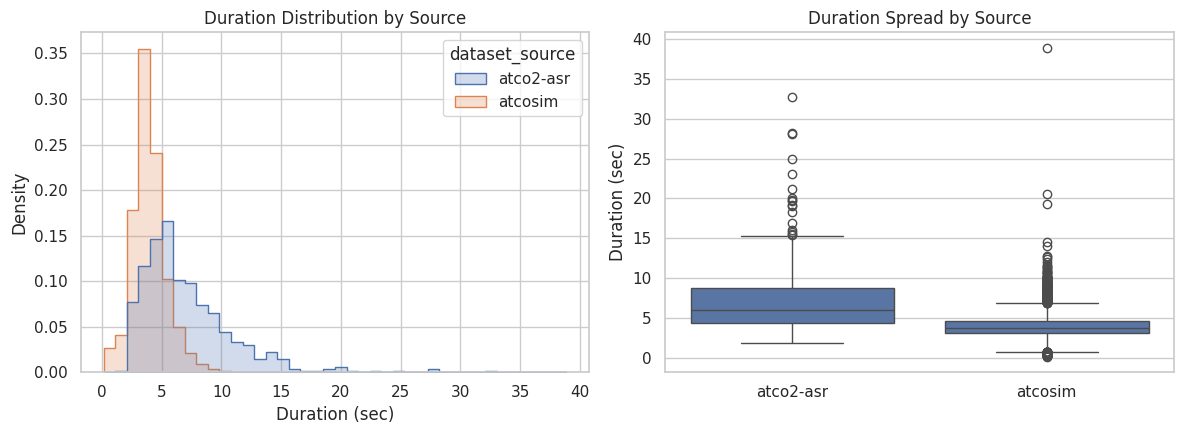

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(
    data=utterance_df, x="duration_sec", hue="dataset_source", bins=40,
    element="step", stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("Duration Distribution by Source")
axes[0].set_xlabel("Duration (sec)")

sns.boxplot(data=utterance_df, x="dataset_source", y="duration_sec", ax=axes[1])
axes[1].set_title("Duration Spread by Source")
axes[1].set_xlabel("")
axes[1].set_ylabel("Duration (sec)")

plt.tight_layout()
save_fig(fig, "duration_distribution_and_spread_by_source")
plt.show()

**Observation:** The histogram on the left shows the two distributions occupy different territory, not just different averages: **ATCOSIM** is tight and concentrated in the 3-5s range, while **ATCO2-ASR** is broader and shifted right, spread from about 2s out past 15s with a long tail to ~33s. The boxplot on the right flips that story for outliers: ATCOSIM's narrow interquartile range (`4.63 - 3.08 = 1.55s`) means both its shortest clips (e.g., near-zero-duration utterances) *and* its single longest clip in the whole combined dataset (~38.9s, which is longer than ATCO2-ASR's max) get flagged as statistical outliers, while ATCO2-ASR's naturally wider spread (`8.70 - 4.35 = 4.35s` IQR) absorbs more of its own variability without registering as many extremes. Thus, ATCO2-ASR is consistently longer on average, but ATCOSIM is where the true extremes, both shortest and longest, actually live.

In [26]:
# Flag near-empty clips (< 0.5s) which are likely single-word/backchannel utterances
# (e.g., "yeah", "roger") that may need special handling (or filtering) for ASR training.
short_clip_threshold = 0.5
short_clips = utterance_df[utterance_df["duration_sec"] < short_clip_threshold]
print(f"Clips under {short_clip_threshold}s: {len(short_clips)} ({len(short_clips) / len(utterance_df):.2%} of all utterances)")
display(short_clips["dataset_source"].value_counts())
short_clips.nsmallest(5, "duration_sec")[["dataset_source", "duration_sec", "word_count", "transcript"]]

Clips under 0.5s: 44 (0.43% of all utterances)


dataset_source
atcosim    44
Name: count, dtype: int64

,dataset_source,duration_sec,word_count,transcript
1646,atcosim,0.140750,1,yeah
1768,atcosim,0.194875,1,yeah
6237,atcosim,0.232250,1,roge
5959,atcosim,0.237437,1,okay
8030,atcosim,0.243188,1,roger


**Observation:** All 44 sub-0.5s clips are from **ATCOSIM**, and they're overwhelmingly single-word acknowledgments (e.g., `yeah`, `roger`, `okay`, etc.) rather than truncated or corrupted recordings. This confirms what the boxplot outliers above were pointing at: ATCOSIM's tight duration distribution still has real, legitimate outliers at the bottom end. While these outliers may have some influence on the performance of a model, they are not necessarily a data-quality defect to fix here. We'll defer to later model pre-processing steps in this project (not in this notebook).

#### `word_count` & `character_count`
**NOTE:** Since `word_count` and `character_count` naturally positively correlate with each other, the more worthwhile comparison will be across the data sources (e.g., `ATCO2-ASR` vs. `ATCOSIM`).

word_count                                             \
                    count   mean    std  min   25%   50%   75%   max   
dataset_source                                                         
atco2-asr           559.0  19.14  10.33  5.0  12.0  16.0  23.0  88.0   
atcosim            9559.0  11.29   4.17  1.0   9.0  11.0  13.0  71.0   

               character_count                                                
                         count   mean    std   min   25%   50%    75%    max  
dataset_source                                                                
atco2-asr                559.0  110.7  61.06  30.0  70.0  94.0  135.0  525.0  
atcosim                 9559.0   64.7  23.86   2.0  50.0  64.0   76.0  331.0

Saved figure: ../res/figures/word_and_character_count_distribution_by_source.png


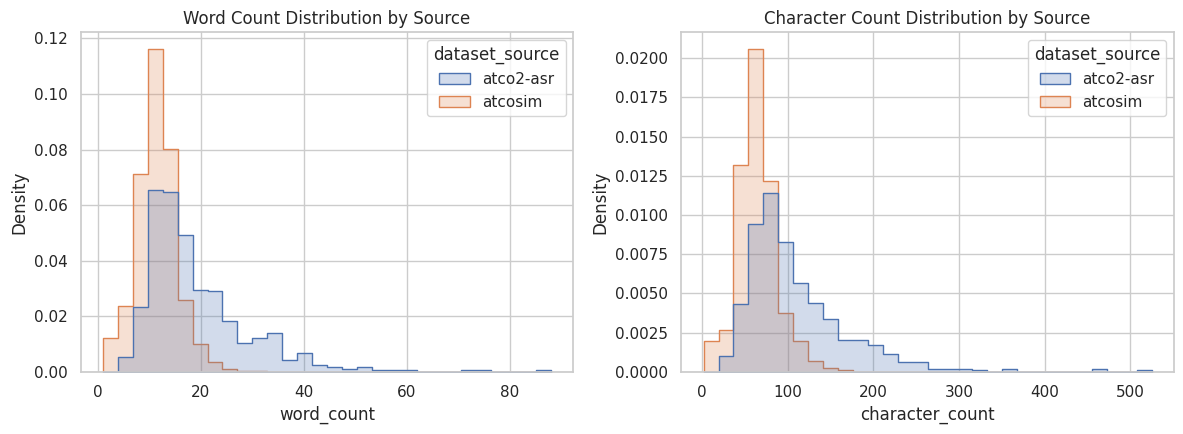

In [27]:
display(utterance_df.groupby("dataset_source")[["word_count", "character_count"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(
    data=utterance_df, x="word_count", hue="dataset_source", bins=30,
    element="step", stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("Word Count Distribution by Source")

sns.histplot(
    data=utterance_df, x="character_count", hue="dataset_source", bins=30,
    element="step", stat="density", common_norm=False, ax=axes[1],
)
axes[1].set_title("Character Count Distribution by Source")

plt.tight_layout()
save_fig(fig, "word_and_character_count_distribution_by_source")
plt.show()

**Observation:** Same pattern as `duration_sec`: **ATCO2-ASR** transcripts run almost twice as long by both word count (`mean~19.1` vs `~11.3` words) and character count (`mean~110.7` vs `~64.7` chars), and with much more spread (`std~10.3` words vs `~4.2`). This makes sense because real-world transmissions tend to bundle more instructions/readbacks into a single utterance compared to ATCOSIM's shorter, more uniform scripted phrases. However, there's more anlaysis needed since this doesn't actually give an answer as to *why* they're longer. For instance, it could be due to more content or just spoken slower. `speech_rate_wpm` can be used to answer this question.

#### `speech_rate_wpm`
`duration_sec` and `word_count` are more informative when combined rather than separate. Dividing one by the other gives speech rate (words/minute). This helps answer the question on whether ATCO2-ASR's longer, wordier utterances are actually spoken slower/faster than ATCOSIM's, or are they just longer? The `DataIngestPipeline` derives this directly (`word_count / (duration_sec / 60)`) as a `speech_rate_wpm` column.

,count,mean,std,min,25%,50%,75%,max
dataset_source,,,,,,,,
atco2-asr,559.0,168.4,36.0,32.3,147.5,167.7,191.5,279.3
atcosim,9559.0,174.4,37.9,19.2,151.1,176.6,200.1,428.0


Saved figure: ../res/figures/speech_rate_by_source.png


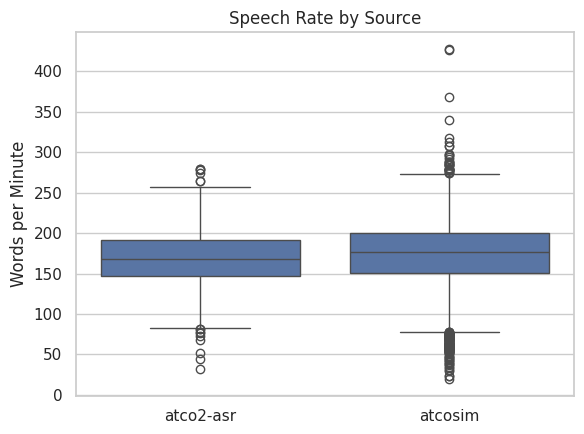

In [28]:
display(utterance_df.groupby("dataset_source")["speech_rate_wpm"].describe().round(1))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=utterance_df, x="dataset_source", y="speech_rate_wpm", ax=ax)
ax.set_title("Speech Rate by Source")
ax.set_xlabel("")
ax.set_ylabel("Words per Minute")
plt.tight_layout()
save_fig(fig, "speech_rate_by_source")
plt.show()

**Observation:** Speech rate is close between sources (`mean~168` wpm for ATCO2-ASR vs `~174` wpm for ATCOSIM), despite ATCO2-ASR's utterances running almost twice as long in both duration and word count. Given this, we can conclude that controllers and pilots in the real **ATCO2-ASR** dataset are saying more per utterance (e.g., more instructions, readbacks, context, etc.) compared to the utterances in the **ATCOSIM** dataset. In other words, the content of the utterances in the ATCO2-ASR dataset are actually longer than the ATCOSIM dataset. This is good insight for training a model since it means we can rely on duration by itself for content/complexity across the data sources without having to separate out a speech-rate correction (for example).

#### `dataset_split` & `original_split`
`original_split`: the split each row belonged to *within its own source dataset*, before joining

`dataset_split`: the split the original split landed in *after* joining. 

`DataIngestPipeline` currently only concatenates matching split names (source `train` -> combined `train`, etc.) rather than re-splitting across sources, so we'll need to check whether these two columns actually carry different information yet.

In [29]:
print("dataset_split value counts:")
print(utterance_df["dataset_split"].value_counts(), "\n")

print("original_split value counts:")
print(utterance_df["original_split"].value_counts(), "\n")

identical = (utterance_df["dataset_split"] == utterance_df["original_split"]).all()
print(f"dataset_split == original_split for every row: {identical}")
# if identical:
#     print(
#         "\nThe two columns are currently redundant: the pipeline joins train-with-train and "
#         "validation-with-validation, so no row's split changes during the join. original_split "
#         "still earns its keep as the join's audit trail (and matters the moment either dataset's "
#         "split boundaries change, or the combined data gets re-split for modeling)."
#     )
# else:
#     print("")

dataset_split value counts:
dataset_split
train         8092
validation    2026
Name: count, dtype: int64 

original_split value counts:
original_split
train         8092
validation    2026
Name: count, dtype: int64 

dataset_split == original_split for every row: True


**Observation:** `dataset_split` value counts and `original_split` value counts columns are currently redundant. Since the pipeline joins train-with-train and validation-with-validation, no row's split changes during the join. We'll proceed with `original_split` for traceability purposes from before the join. It will help if either dataset's split boundaries change or if the combined data gets re-split for modeling later on.

Saved figure: ../res/figures/row_count_by_split_and_source.png


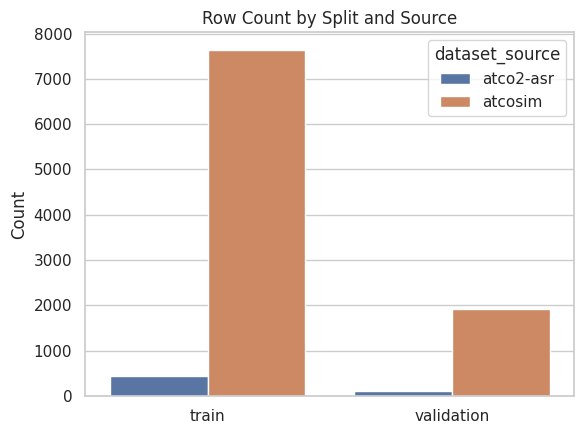

In [30]:
# Since dataset_split and original_split are identical, we can just use a single chart to cover both to analyze split size by source.
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.countplot(data=utterance_df, x="original_split", hue="dataset_source", ax=ax)
ax.set_title("Row Count by Split and Source")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
save_fig(fig, "row_count_by_split_and_source")
plt.show()

**Observation:** This chart makes the imbalance very clear. ATCOSIM's bars dwarf ATCO2-ASR's in both splits, at roughly the same ratio in each. This consistency across train/validation is useful. It indicates the imbalance isn't an artifact of how one split happened to be sampled. Instead, it's baked into the two source datasets themselves.

**Key takeaways:**
- `sample_rate` is a constant (16000 Hz) across all 10,118 rows, confirming the pipeline's resampling step applied uniformly.
- `duration_sec`: ~11.55 total hours of audio, but split unevenly by *hours* (not just row count): ATCOSIM at approximately 90.5% and ATCO2-ASR at approximately 9.5%. ATCO2-ASR clips run almost twice as long on average (approximately 7.1s vs approximately 3.9s), so its 5.5% row-share undersells its actual training signal. A small number of near-silent (<0.5s) ATCOSIM clips (e.g., "yeah", "roger", etc.) may be worth filtering before Automatic Speech Recognition (ASR) training.
- `word_count` / `character_count`: ATCO2-ASR transcripts are consistently longer (approximately 19 words vs approximately 11) and more variable, which is consistent with real, less scripted ATC exchanges vs. ATCOSIM's more uniform simulated phrasing.
- Despite this, **speech rate (wpm) is close between sources** (approximately 168 vs approximately 174 wpm), so the transcript-length gap is really utterances containing more content rather than being read faster or slower.
- `dataset_split` and `original_split` are identical for every row since the data ingest pipeline process only joins matching splits, making it redundant. However, `original_split` is worth keeping as it stops being redundant when the combined data gets re-split for modeling.

### Validate the Join & Document Imbalance
The core data ingest pipeline process (`DataIngestPipeline.run()`) asserts that the combined row count matches the sum of the two source datasets' row counts and that every `utterance_id` is unique. If either check had failed, the process would have raised an exception. The validation report (`validation_report_`) breaks the confirmed counts down by `dataset_source` per split, which is also where the class imbalance between the two corpora becomes evident.

In [31]:
pipeline.validation_report_

,original_split,dataset_source,row_count,pct_of_split
0,train,atco2-asr,446,5.5
1,train,atcosim,7646,94.5
2,validation,atco2-asr,113,5.6
3,validation,atcosim,1913,94.4


In [32]:
# Summarize the imbalance for the training split since that's what the model(s) will actually be fit on.
train_counts = pipeline.validation_report_.query("original_split == 'train'").set_index("dataset_source")["row_count"]
majority_source, minority_source = train_counts.idxmax(), train_counts.idxmin()
imbalance_ratio = train_counts[majority_source] / train_counts[minority_source]

print(
    f"Training split is dominated by '{majority_source}' ({train_counts[majority_source]} rows) vs. '{minority_source}' ({train_counts[minority_source]} rows)"
)

print(f"Imbalance ratio (majority:minority) in training split: {imbalance_ratio:.1f}:1")

Training split is dominated by 'atcosim' (7646 rows) vs. 'atco2-asr' (446 rows)
Imbalance ratio (majority:minority) in training split: 17.1:1


**Observation:** Given the `17.1:1` imbalance, we'll need to address this for model training/evaluation. For instance, we can use stratified sampling, per-source metrics, or class weighting. It will be interesting to see how additional noise influences model performance between the `ATCO2-ASR` and `ATCOSIM` datasets.

## Data Quality Checks
Before trusting `utterance_df`/`combined_dataset` for modeling, we need to run it through the checks a real ASR training pipeline would fail on silently otherwise such as missing/blank fields, unreadable or zero-length audio, and duplicate rows.

#### Missing audio
We need to check if every row's audio is actually decoded. We can rely on the fact that `duration_sec`/`sample_rate` was derived from the decoded array for all 10,118 rows without the pipeline raising an exception. To be thorough, we can re-verify directly by checking for any records with a null or empty string `audio_path` as well as any missing audio decodings.

In [33]:
missing_audio_path = (utterance_df["audio_path"].isna() | (utterance_df["audio_path"].str.strip() == "")).sum()
print(f"Rows with missing/blank audio_path: {missing_audio_path}")

missing_audio_decode = sum(
    1 for split in combined_dataset.values() for a in split["audio"] if a is None
)
print(f"Rows where audio failed to decode (null 'audio' entries): {missing_audio_decode}")

Rows with missing/blank audio_path: 0
Rows where audio failed to decode (null 'audio' entries): 0


#### Missing & blank transcripts
We need to check for two different edge case scenarios with the ground truth transcript field:
1) `transcript` being null (the field is entirely absent).
2) `transcript` being non-null but empty/whitespace-only after stripping (present but carries no content).

In [34]:
missing_transcript = utterance_df["transcript"].isna().sum()
blank_transcript = (utterance_df["transcript"].fillna("").str.strip() == "").sum()
print(f"Missing (null) transcripts: {missing_transcript}")
print(f"Blank (empty/whitespace, non-null) transcripts: {blank_transcript}")

Missing (null) transcripts: 0
Blank (empty/whitespace, non-null) transcripts: 0


#### Missing & structurally unavailable metadata
Two different situations get conflated if you only look at null counts.
1) A field that's *sometimes* missing within a source (e.g., a real per-row gap) 
2) A field that's *never present for an entire source* because that source's schema simply doesn't include it. 

Based on the original data source schemas, `info` falls into the second category since the `ATCOSIM` dataset does not have it.

In [35]:
info_nulls_by_source = utterance_df.groupby("dataset_source")["info"].apply(lambda s: s.isna().sum())
info_rows_by_source = utterance_df["dataset_source"].value_counts()
print("`info` null counts by source (vs. total rows for that source):")
display(pd.DataFrame({"null_info": info_nulls_by_source, "total_rows": info_rows_by_source}))

speaker_role_present = "speaker_role" in utterance_df.columns
print(f"\n`speaker_role` column present: {speaker_role_present}.")

`info` null counts by source (vs. total rows for that source):


,null_info,total_rows
dataset_source,,
atco2-asr,0,559
atcosim,9559,9559



`speaker_role` column present: False.


**Observation:** `info` is null for every ATCOSIM row and populated for every ATCO2-ASR row. ATCOSIM's source schema never included it. Fortunately, this is not an issue with missing data.

`speaker_role` is a column sought out to train a model for speaker role classification (or tagging). Unfortunately, since it is not present in neither the ATCO2-ASR dataset nor the ATCOSIM dataset, we'll either need to take a zero-shot approach (e.g., find a fine-tuned model for speaker role classification) or skip training a model for speaker role classification.

#### Zero-duration or unreadable audio
"Unreadable" is already covered by the missing-audio decode check above (0 failures across all 10,118 rows). As additional thoroughness, we should check for zero/near-zero-length clips which decode fine but carry essentially no value.

In [36]:
zero_duration = (utterance_df["duration_sec"] <= 0).sum()
print(f"Zero (or negative) duration rows: {zero_duration}")
print(f"Shortest clip: {utterance_df['duration_sec'].min():.3f}s")

Zero (or negative) duration rows: 0
Shortest clip: 0.141s


#### Duplicate IDs, file paths, and audio/transcript pairs
Three different duplication questions: 
1) Are `utterance_id`s unique (join integrity; `DataIngestPipeline` already asserts this, re-checked here)?
2) Do any rows point at the *same audio file* (would mean double-counting the same recording)?
3) Do any rows share *both* the same audio and the same transcript (a true duplicate row)?

In [37]:
dup_ids = utterance_df["utterance_id"].duplicated().sum()
dup_paths_within_source = utterance_df.duplicated(subset=["dataset_source", "audio_path"], keep=False).sum()
dup_paths_overall = utterance_df["audio_path"].duplicated(keep=False).sum()
dup_pairs = utterance_df.duplicated(subset=["audio_path", "transcript"], keep=False).sum()

print(f"Duplicate utterance_id:                          {dup_ids}")
print(f"Duplicate audio_path (within same source):       {dup_paths_within_source}")
print(f"Duplicate audio_path (across the whole dataset):  {dup_paths_overall}")
print(f"Duplicate (audio_path, transcript) pairs:         {dup_pairs}")

Duplicate utterance_id:                          0
Duplicate audio_path (within same source):       0
Duplicate audio_path (across the whole dataset):  0
Duplicate (audio_path, transcript) pairs:         0


**Observation:** Fortunately, there's no duplication across the joined utterances dataset.

#### Repeated transcript text
Apart from identifying any duplicate transcripts, we should see if there's any transcripts with repeated words spoke in more than one utterance. Since ATC phrasing is standardized, it likely there's some level of repetition expected.  

In [38]:
transcript_counts = utterance_df["transcript"].value_counts()
repeated = transcript_counts[transcript_counts > 1]
n_repeated_rows = repeated.sum()

print(f"Unique transcripts: {utterance_df['transcript'].nunique():,} / {len(utterance_df):,} rows")
print(f"Rows whose transcript text appears more than once: {n_repeated_rows:,} ({n_repeated_rows / len(utterance_df):.1%})\n")
print("Most-repeated transcripts:")
display(repeated.head(10))

Unique transcripts: 8,146 / 10,118 rows
Rows whose transcript text appears more than once: 3,004 (29.7%)

Most-repeated transcripts:


transcript
roger                                                                                  47
affirm                                                                                 30
thank you                                                                              22
contact milan one three four five two good bye                                         15
okay                                                                                   12
yeah                                                                                   11
station calling                                                                        10
sabena eight two six alfa good morning squawk seven five three one                      8
alitalia six four seven four contact rhein radar one two seven decimal three seven      8
lufthansa three five five zero contact zurich one three four decimal six                8
Name: count, dtype: int64

**Observation:** The top repeats are standard ATC acknowledgments (e.g., "roger" x47, "affirm" x30, "thank you" x22, etc.) and standard callsign/frequency handoffs (e.g., "contact milan one three four five two good bye" x15). This is exactly the kind of fixed phrasing we'd expect from ATC communications. The duplicate-pairs check above already found **0** rows sharing both the same `audio_path` *and* transcript, so every repeated transcript here comes from a distinct recording.

### Data Quality Summary & Proposed Handling

| Check | Result | Proposed handling |
| --- | --- | --- |
| Missing audio (path or decode failure) | 0 / 10,118 | None needed. |
| Missing transcripts (null) | 0 / 10,118 | None needed. |
| Blank transcripts (empty/whitespace) | 0 / 10,118 | None needed. |
| `info` missing | Null for all 9,559 ATCOSIM rows, populated for all 559 ATCO2-ASR rows | Structural, not a defect. Leave nullable; don't impute. Any feature built from `info` only applies to ATCO2-ASR. |
| `speaker_role` missing | Absent from both source schemas (100%) | Out of scope for this pass; would need external annotation or a heuristic derived from phrasing if speaker-role modeling becomes a requirement. |
| Zero-duration / unreadable audio | 0 / 10,118 | None needed. |
| Near-zero-duration clips (<0.5s) | 44 rows, all ATCOSIM, mostly single-word acknowledgments | Flag, don't drop yet; revisit filtering once a specific model's minimum input length is known. |
| Duplicate `utterance_id` | 0 | None needed (join integrity already enforced by `DataIngestPipeline`). |
| Duplicate `audio_path` (within source or overall) | 0 | None needed; also rules out train/validation leakage via duplicate audio. |
| Duplicate (`audio_path`, `transcript`) pairs | 0 | None needed. |
| Repeated transcript text | 3,004 / 10,118 rows (29.7%) share text with another row | Keep; confirmed to reflect standardized ATC phrasing across distinct recordings, not duplicate data. |

**Bottom line:** the combined dataset is clean on every hard-failure check (e.g., nulls, blanks, unreadable/zero-length audio, duplicate rows). Nothing needs to be dropped before further EDA and modeling preparation. The two open items are both scope/labeling gaps rather than defects: 
1) `speaker_role` isn't available from either source.
2) The 44 near-zero-duration clips (a training-time filtering decision and not a data-quality fix).

## Preliminary EDA

### Representative Audio Samples (per Corpus)
In order to assemble a representative set of audio samples, we need to pick them by duration rather than just picking the first few rows. To achieve this, we can target one of the three utterances closest to its corpus's *median* `duration_sec`. This ensures that we look at a typical-length clip for that source and not an outlier. We can then use the `render_audio_table` function to play the audio with its transcript shown alongside (similar to the Hugging Face (HF) Hub's dataset viewer).

In [39]:
def render_audio_table(dataset, n=5, start=0, audio_col="audio", text_cols=None, max_text_len=160, save_dir=None):
    """Render an HTML table of `n` rows starting at `start`, with an inline,
    playable <audio> element per row alongside its other column values,
    a notebook-friendly stand-in for the HF Hub's dataset viewer table.

    Args:
        dataset: a `datasets.Dataset` (a single split, e.g. `ds["train"]`) or
            a plain list of row dicts (e.g. rows gathered from different
            splits via `get_dataset_row`).
        n: number of rows to render.
        start: row index to start from.
        audio_col: name of the audio feature column.
        text_cols: columns to show alongside the player; defaults to every
            non-audio column.
        max_text_len: truncate long text/metadata fields to this many chars.
        save_dir: if given, also write each row's audio to
            `<save_dir>/<utterance_id or row index>.wav` and add a "file"
            column linking to it (link text is the filename).

    Returns:
        An `IPython.display.HTML` object; display it or let it be the last
        expression in a cell.
    """
    column_names = getattr(dataset, "column_names", None) or list(dataset[0].keys())
    if text_cols is None:
        text_cols = [c for c in column_names if c != audio_col]

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    def _cell_style(extra=""):
        return f"border:1px solid #ddd; padding:6px 10px; text-align:left; vertical-align:top; {extra}"

    extra_header = ["file"] if save_dir is not None else []
    header_cells = "".join(
        f'<th style="{_cell_style("background:#f5f5f5;")}">{html_lib.escape(c)}</th>'
        for c in ["#", audio_col, *text_cols, *extra_header]
    )

    body_rows = []
    for i in range(start, min(start + n, len(dataset))):
        row = dataset[i]
        audio = row[audio_col]

        buf = io.BytesIO()
        sf.write(buf, audio["array"], audio["sampling_rate"], format="WAV")
        wav_bytes = buf.getvalue()
        b64_audio = base64.b64encode(wav_bytes).decode("ascii")
        player_html = (
            # preload="metadata" (not "none"): the audio is already fully embedded
            # as a data URI, so this costs no extra network request, but it lets
            # the browser read the duration immediately instead of showing 0:00/0:00
            # until playback starts.
            f'<audio controls preload="metadata" style="width:220px">'
            f'<source src="data:audio/wav;base64,{b64_audio}" type="audio/wav">'
            f"</audio>"
        )

        cells = [
            f'<td style="{_cell_style()}">{i}</td>',
            f'<td style="{_cell_style()}">{player_html}</td>',
        ]
        for col in text_cols:
            text = html_lib.escape(str(row[col])).replace("\n", "<br>")
            if len(text) > max_text_len:
                text = text[:max_text_len] + "…"
            cells.append(f'<td style="{_cell_style("max-width:320px; white-space:normal;")}">{text}</td>')

        if save_dir is not None:
            file_stem = str(row.get("utterance_id", i))
            file_name = f"{file_stem}.wav"
            file_path = os.path.join(save_dir, file_name)
            with open(file_path, "wb") as f:
                f.write(wav_bytes)
            href = os.path.relpath(file_path, os.getcwd())
            cells.append(f'<td style="{_cell_style()}"><a href="{href}" target="_blank">{html_lib.escape(file_name)}</a></td>')

        body_rows.append("<tr>" + "".join(cells) + "</tr>")

    table_html = f"""
    <table style="border-collapse:collapse; font-family:sans-serif; font-size:13px;">
      <thead><tr>{header_cells}</tr></thead>
      <tbody>{''.join(body_rows)}</tbody>
    </table>
    """
    return HTML(table_html)

In [40]:
# Build a utterance_id -> (split, position) lookup once.
# utterance_id is a plain string column (no audio decode triggered), so any
# later cell can pull a specific row's decoded audio out of combined_dataset
# without re-scanning it (used for representative-sample selection below, and
# again for the waveform/spectrogram plots).
utterance_id_index = {
    uid: (split_name, pos)
    for split_name, split in combined_dataset.items()
    for pos, uid in enumerate(split["utterance_id"])
}


def get_dataset_row(utterance_id):
    """Fetch one row (with decoded audio) from combined_dataset by utterance_id."""
    split_name, pos = utterance_id_index[utterance_id]
    return combined_dataset[split_name][pos]


def select_representative_rows(source_name, n=3):
    """Return the `n` utterance_ids for `source_name` closest to its median duration_sec."""
    subset = utterance_df[utterance_df["dataset_source"] == source_name]
    median_duration = subset["duration_sec"].median()
    closest = subset.loc[(subset["duration_sec"] - median_duration).abs().sort_values().index[:n]]
    return closest["utterance_id"].tolist()

In [41]:
representative_ids = select_representative_rows("atco2-asr", n=2) + select_representative_rows("atcosim", n=2)
representative_rows = [get_dataset_row(uid) for uid in representative_ids]

render_audio_table(
    representative_rows,
    n=len(representative_rows),
    text_cols=["utterance_id", "dataset_source", "text", "duration_sec", "word_count"],
    save_dir=AUDIO_SAMPLES_DIR,
)

#,audio,utterance_id,dataset_source,text,duration_sec,word_count,file
0,,atco2-asr-validation-000078,atco2-asr,United One Three Five wind zero three zero degrees one zero knots runway two eight cleared takeoff,6.016,17,atco2-asr-validation-000078.wav
1,,atco2-asr-train-000002,atco2-asr,Ryanair Seven Three Alpha Hotel turn left heading three six zero Ryanair Seven Three Alpha Hotel,6.016,16,atco2-asr-train-000002.wav
2,,atcosim-train-005268,atcosim,spar eight nine report your heading to zurich on one three three four good bye,3.77725,15,atcosim-train-005268.wav
3,,atcosim-train-006577,atcosim,airfrans three two six one good afternoon squawk two seven two four,3.7775625,12,atcosim-train-006577.wav


### Waveform & Mel Spectrogram
Targeting one representative sample per corpus (the same median-duration picks as above), shown as both a raw waveform (amplitude over time) and a mel spectrogram (frequency content over time, closer to what an ASR model's feature extractor actually consumes).

Saved figure: ../res/figures/waveform_and_mel_spectrogram_by_source.png


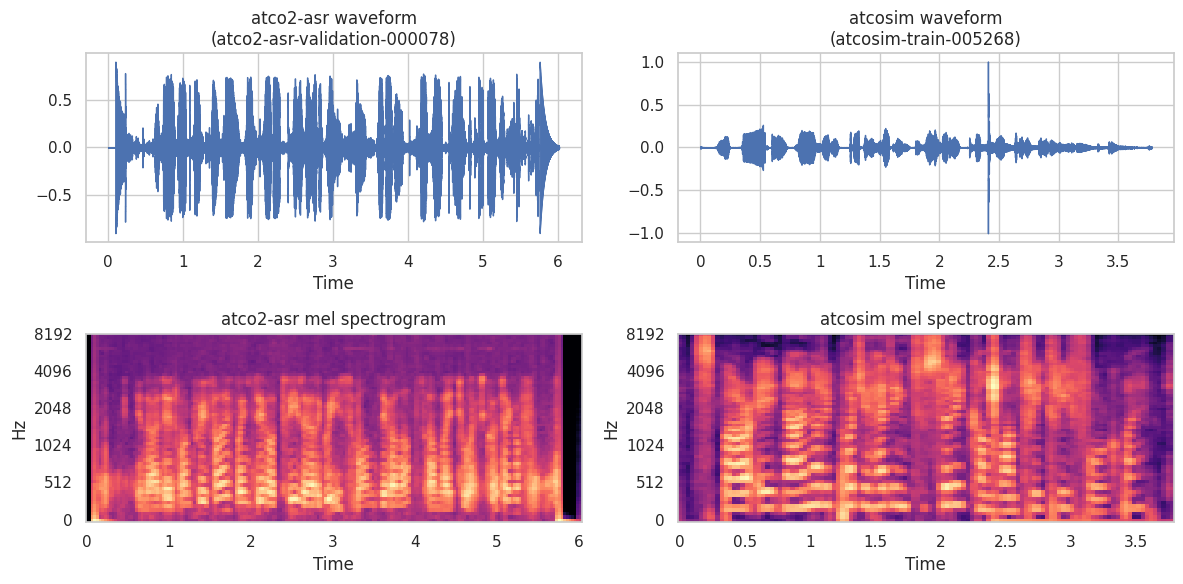

In [42]:
waveform_sample_ids = {"atco2-asr": representative_ids[0], "atcosim": representative_ids[2]}

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for col, (source, uid) in enumerate(waveform_sample_ids.items()):
    row = get_dataset_row(uid)
    y = row["audio"]["array"].astype(np.float32)
    sr = row["audio"]["sampling_rate"]

    librosa.display.waveshow(y, sr=sr, ax=axes[0, col])
    axes[0, col].set_title(f"{source} waveform\n({uid})")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, col])
    axes[1, col].set_title(f"{source} mel spectrogram")

plt.tight_layout()
save_fig(fig, "waveform_and_mel_spectrogram_by_source")
plt.show()

**Observation:** Both representative spectrograms show the expected shape with speech energy concentrated in the lower mel bins, clear voice-activity segments. But the ATCOSIM waveform above has a single full-scale (amplitude 1.0) transient spike around the 2.4s mark (a brief click/pop) that the duration/zero-audio checks in Data Quality Checks wouldn't catch. Also, the ATCO2-ASR waveform appears to have a lot more noise compared to the ATOCSIM waveform which makes sense given that ATCO2-ASR represents real ATC communications while ATCOSIM is simulated in a controlled environment. It's worth a dedicated clipping/artifact scan across the full corpus before training and perhaps even applying a noise filtering algorithm if necessary.

### ATCO2 `info`/Annotation Examples
`info` (ATCO2-ASR only; see Data Quality Checks) is a multi-line text block per recording:
* Airport ICAO code
* Airport/facility name
* Position (e.g. Radar/Tower)
* A list of published waypoints near that airport
* The callsigns and airline names observed in the recording

Distinct airports in ATCO2-ASR: 7


airport_icao
LSGS    159
LSZB    124
LSZH     94
YSSY     71
LKPR     46
LZIB     42
LKTB     23
Name: count, dtype: int64

Saved figure: ../res/figures/atco2_asr_utterance_count_by_airport.png


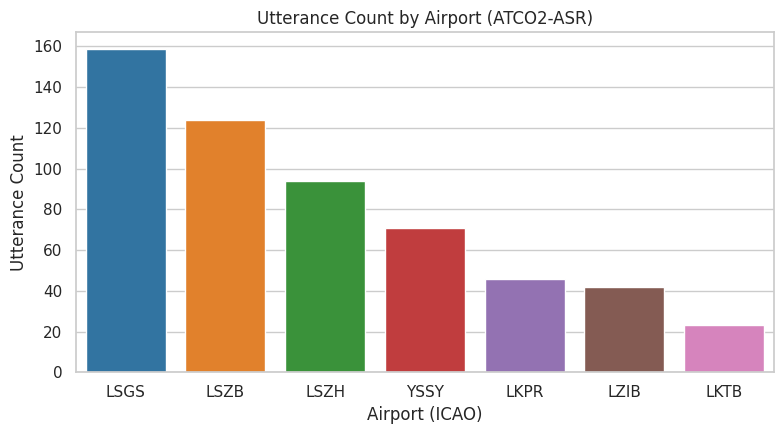

In [43]:
# Determine spread of distinct airports across the ATCO2-ASR dataset
atco2_df = utterance_df[utterance_df["dataset_source"] == "atco2-asr"].copy()
atco2_df["airport_icao"] = atco2_df["info"].str.split("\n").str[0]

airport_counts = atco2_df["airport_icao"].value_counts()
print(f"Distinct airports in ATCO2-ASR: {airport_counts.nunique() and len(airport_counts)}")
display(airport_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=airport_counts.index, y=airport_counts.values, hue=airport_counts.index, palette="tab10", legend=False, ax=ax)
ax.set_title("Utterance Count by Airport (ATCO2-ASR)")
ax.set_xlabel("Airport (ICAO)")
ax.set_ylabel("Utterance Count")
plt.tight_layout()
save_fig(fig, "atco2_asr_utterance_count_by_airport")
plt.show()

**Observation:** ATCO2-ASR dataset spans 7 distinct airports across its 559 rows.

#### Recording Date Range
The audio filenames in the ATCO2-ASR dataset embed a recording date/time (e.g.,
`LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav` → 2020-10-25 09:11:12). The `DataIngestPipeline`
parses this into a `recorded_at` column (ISO-8601 string, `None` for ATCOSIM, whose generic
filenames don't embed a date), so the actual range can be reported instead of "TBD."

Recording date range (ATCO2-ASR): 2020-10-25 09:09:15 to 2021-05-05 23:49:13
Span: 192 days


,min,max,count
airport_icao,,,
LKPR,2020-10-25 09:09:15,2020-10-29 20:51:25,46
LKTB,2020-10-26 09:27:27,2020-10-29 18:02:05,23
LSGS,2021-04-15 10:34:08,2021-05-05 15:58:03,159
LSZB,2021-04-13 09:35:20,2021-04-25 16:20:33,124
LSZH,2021-04-12 14:43:35,2021-04-24 16:07:22,94
LZIB,2021-04-23 12:08:26,2021-05-05 22:52:41,42
YSSY,2021-04-27 04:28:38,2021-05-05 23:49:13,71


Saved figure: ../res/figures/atco2_asr_recording_date_range_by_airport.png


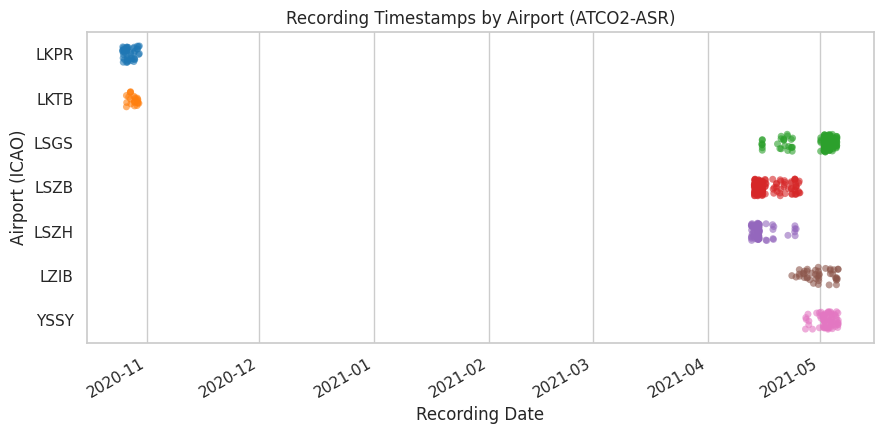

In [44]:
atco2_df["recorded_at"] = pd.to_datetime(atco2_df["recorded_at"])

print(f"Recording date range (ATCO2-ASR): {atco2_df['recorded_at'].min()} to {atco2_df['recorded_at'].max()}")
print(f"Span: {(atco2_df['recorded_at'].max() - atco2_df['recorded_at'].min()).days} days")

date_range_by_airport = atco2_df.groupby("airport_icao")["recorded_at"].agg(["min", "max", "count"])
display(date_range_by_airport)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.stripplot(
    data=atco2_df, x="recorded_at", y="airport_icao", hue="airport_icao",
    palette="tab10", legend=False, jitter=0.2, alpha=0.6, ax=ax,
)
ax.set_title("Recording Timestamps by Airport (ATCO2-ASR)")
ax.set_xlabel("Recording Date")
ax.set_ylabel("Airport (ICAO)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "atco2_asr_recording_date_range_by_airport")
plt.show()

**Observation:** ATCO2-ASR's recordings span 2020-10-25 to 2021-05-05 (192 days), but that range hides the real structure: it's not one continuous collection window, it's two distinct recording waves about 6 months apart. LKPR and LKTB were both recorded in a narrow window at the end of October 2020, while LSGS, LSZB, LSZH, LZIB, and YSSY were all recorded in April-May 2021. Worth keeping in mind for modeling: any date-correlated recording-condition changes (equipment, weather, traffic patterns) would line up with *which airports* are in the data, not just *when*.

In [45]:
# Look at two example airports to capture the range (atco2_df defined above).
example_airports = ["LKPR", "YSSY"]  # a European (Prague) and a non-European (Sydney) example
for airport in example_airports:
    example = atco2_df[atco2_df["info"].str.startswith(airport)].iloc[0]
    print(f"--- utterance_id: {example['utterance_id']} | transcript: {example['transcript'].strip()!r} ---")
    print(example["info"])
    print()

--- utterance_id: atco2-asr-train-000000 | transcript: 'Oscar Kilo Papa Mike Bravo descend flight level one hundred level one hundred Oscar Kilo Papa Mike Bravo' ---
LKPR
Praha Ruzyne
Radar
AKEVA ARVEG BAGRU BAROX BAVIN BEKVI ELMEK ELPON ERASU EVEMI KENOK KUVIX LETNA RATEV RISUK SOMIS SULOV TIPRU UTORO
BLA131 BLA1XQ BTI7PY CTN480 DLH3NL DLH9TP ETD72E EWG6HP FIN1DH IRA711 KLM44K MLD863 MLD864 OKHBT OKLLZ OKMHZ OKPHM OKWUS17 OKYAI14 RYR1JU RYR4945 SXS7D THY32B THY6577 TIE790J UAE73  
All Charter Air Baltic Croatia Lufthansa Etihad Eurowings Finn Iranair Klm Moldova Oklahoma Okapi Alfa Ryan Sunexpress Turkish Time Emirates

--- utterance_id: atco2-asr-train-000368 | transcript: 'runway one six right cleared to land pass \xa0Seven \xa0 \xa0Six \xa0 \xa0Seven' ---
YSSY
Sydney
Tower
ABBEY ANKUB ATRET BEROW BIGEM BIKUS BOBIG BOOGI BUVLO CLIFF COONY CORDO DALAR DEENA DIPPA DUDOK DUMOP DUNES ENDEV ENKAS ENTRA FISHA GOMUB HALAS HOOKS IGALA ISMER JAKLN JELLI JENTL JULIA KABLO KAMBA KAMPI KEVIN LA

### Preliminary Findings

1. **Severe imbalance, by both row count and audio hours.** ATCOSIM makes up 94.5% of rows and 90.5% of total audio hours; ATCO2-ASR is the minority on both counts (~11.55 total hours combined).
2. **Real ATC speech (ATCO2-ASR) is structurally denser than simulated speech (ATCOSIM).** ATCO2-ASR clips run ~1.8x longer (~7.1s vs ~3.9s) and carry ~1.7x more words (~19 vs ~11) on average, yet speech rate is close between sources (~168 vs ~174 wpm). The gap is *content per transmission*. Real ATC communications bundle more instructions/readbacks than ATCOSIM's more uniform scripted phrases.
3. **The data is clean on every hard-failure axis, but not perfectly uniform.** Zero missing/blank transcripts, zero unreadable or zero-duration audio, zero duplicate rows, but 44 ATCOSIM clips run under 0.5s (mostly single-word acknowledgments), and ~29.7% of rows share transcript text with another row. This was expected due to how structured and standardized ATC phrasing is.
4. **Two sought-after feature-dictionary fields don't actually exist in the source data.** `speaker_role` is absent from both schemas entirely. `info` (airport/callsign context) exists only for ATCO2-ASR (7 distinct airports) and is null for all of ATCOSIM. Both are structural gaps.
5. **Audio structure looks correct, but manual inspection caught something the aggregate checks didn't.** The spectrograms have the expected shape but we saw that the ATCOSIM waveform has a spike indicating a popping noise and the ATCO2-ASR waveform has more noise.

### Implications for the Modeling Plan

- **Evaluate per-source.** Given the 17:1 row imbalance and the systematic duration/content differences, a single pooled Word Error Rate (WER)/Character Error Rate (CER) would be dominated by ATCOSIM and could hide poor performance on ATCO2-ASR, which is the source closer to real deployment audio (e.g., overfitting scenario). We'll need to report metrics split by `dataset_source` to confirm and avoid this bias.
- **Consider initial training on the ATCOSIM dataset and fine-tuning on the ATCO2-ASR dataset** (or class-weighted/oversampled training): Training on ATCOSIM alone would likely result in overfitting and lead to poor performance when inferencing an ASR model in an app (production).
- **Decide what to do with the sub-0.5s clips before training**: For example, we can filter clips below a minimum duration, and add an automated clipping-detection pass (peak amplitude / clipped-sample-count per row) across the full corpus.
- **Decide what to do about `speaker_role` not being present or `info` dependent features being only present in the ATCO2-ASR dataset**: Any research question relying on speaker role isn't answerable from either dataset as-is. Anything relying on `info` (airport/callsign context) only applies to the 5.5% of rows from ATCO2-ASR.
- **Batch/length bucketing strategy should account for both data source distributions**: ATCOSIM has shorter, more uniform clips and ATCO2-ASR's longer tail (up to ~33s) needs to be handled without truncating audio transmissions.